# Deteksi Jenis Sampah di Sekitar Kampus dengan Transfer Learning
Pada tugas kali ini kita akan mengklasifikasikan gambar sampah ke dalam 6 kategori (cardboard, glass, metal, paper, plastic, trash) pakai pendekatan transfer learning, bukan bikin CNN dari nol. Jadi kita manfaatkan model yang udah dilatih di ImageNet, terus di sesuaikan bagian akhirnya buat tugas klasifikasi sampah ini.

Alurnya:
1. Load dan eksplorasi dataset
2. Split data jadi train/val/test
3. Siapkan transform + augmentasi
4. Bangun model transfer learning (fixed feature extractor pakai ResNet18)
5. Latih model, lihat kurva training vs validasi
6. Cek apakah overfitting
7. Kalau overfitting, terapkan teknik penanganannya
8. Evaluasi akhir di test set

In [5]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Load Dataset

Dataset yang dipakai adalah Trash Type Image Dataset dari Kaggle, isinya 6 folder kelas: cardboard, glass, metal, paper, plastic, trash. Struktur foldernya udah rapi, jadi bisa langsung dibaca pakai `ImageFolder` dari torchvision.


In [6]:
data_dir = "TrashType_Image_Dataset"

base_dataset = datasets.ImageFolder(data_dir)
class_names = base_dataset.classes
print("Kelas:", class_names)
print("Total gambar:", len(base_dataset))

Kelas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total gambar: 2527


Sekarang kita lihat distribusi jumlah gambar tiap kelas. Ini penting karena kalau ada kelas yang jomplang banget jumlahnya, model bisa bias ke kelas mayoritas.

C:\Users\ASUS TUF GAMING\AppData\Local\Temp\ipykernel_14208\1562156116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


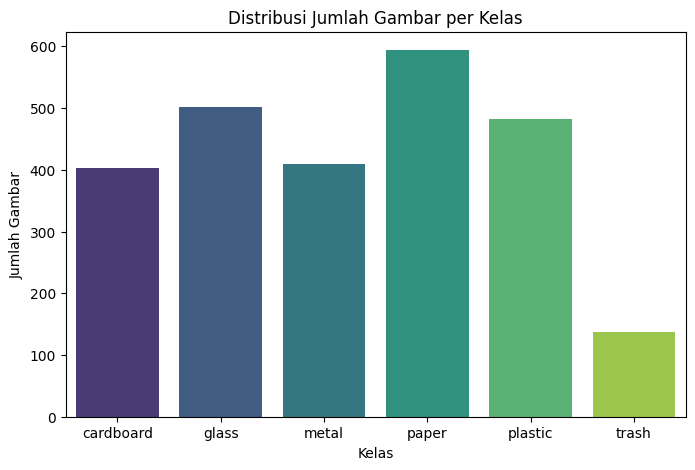

cardboard    403
glass        501
metal        410
paper        594
plastic      482
trash        137
Name: count, dtype: int64

In [7]:
counts = pd.Series([base_dataset.classes[t] for t in base_dataset.targets]).value_counts()
counts = counts.reindex(class_names)

plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

counts

Sekilas ada sedikit ketimpangan (misalnya `trash` jauh lebih sedikit dibanding `paper`), tapi masih dalam batas wajar, jadi kita jalan aja dulu tanpa teknik khusus buat imbalance.

Sekarang kita intip beberapa contoh gambar dari tiap kelas.

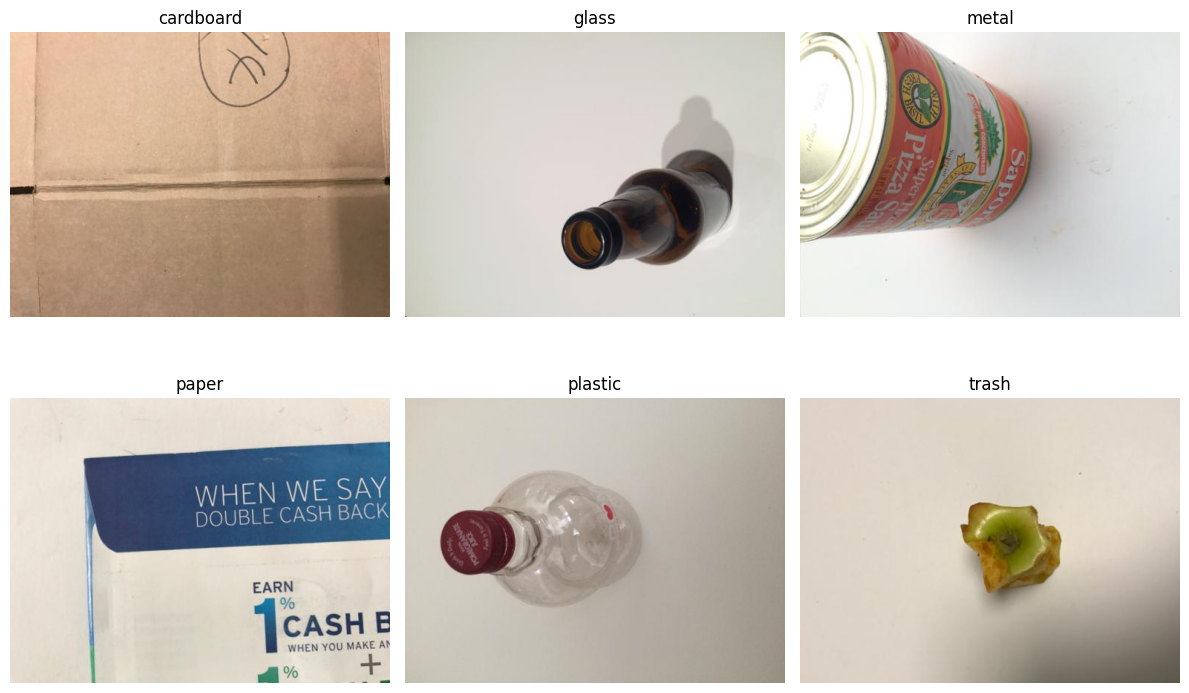

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_idx = class_names.index(cls)
    sample_idx = next(j for j, t in enumerate(base_dataset.targets) if t == cls_idx)
    img, _ = base_dataset[sample_idx]
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2. Split Dataset

Data dibagi jadi tiga: train (70%), validation (15%), test (15%). Split dilakukan secara stratified biar proporsi tiap kelas tetap konsisten di ketiga bagian.

In [9]:
targets = base_dataset.targets
indices = list(range(len(base_dataset)))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, stratify=targets, random_state=SEED
)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=SEED
)

print("Jumlah data train:", len(train_idx))
print("Jumlah data val  :", len(val_idx))
print("Jumlah data test :", len(test_idx))

Jumlah data train: 1768
Jumlah data val  : 379
Jumlah data test : 380


## 3. Transform dan Augmentasi

Untuk data train, kita kasih augmentasi ringan supaya model nggak cuma hafal gambar training tapi belajar variasi juga. Untuk data validasi dan test, kita nggak kasih augmentasi karena kita mau evaluasi apa adanya.

Ukuran gambar di-resize ke 224x224 karena itu ukuran standar input untuk ResNet, dan normalisasinya pakai mean/std dari ImageNet biar sesuai dengan apa yang dipelajari model pretrained.

In [10]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset_full = datasets.ImageFolder(data_dir, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(data_dir, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(eval_dataset_full, val_idx)
test_dataset = Subset(eval_dataset_full, test_idx)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. Bangun Model Transfer Learning

Kita pakai **ResNet18** yang sudah dilatih di ImageNet sebagai base model. Karena dataset kita cuma sekitar 2500 gambar, pendekatan yang dipakai pertama adalah **Fixed Feature Extractor**: semua layer convolutional di-freeze, cuma bagian classifier di ujung yang diganti dan dilatih ulang sesuai jumlah kelas kita (6 kelas).

Alasan pakai pendekatan ini: dataset kita relatif kecil, jadi kalau semua layer dilatih ulang (fine-tuning penuh) risiko overfitting-nya makin besar.

In [11]:
def build_model(num_classes, freeze_backbone=True, dropout=0.0):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    if dropout > 0:
        model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

model = build_model(num_classes=len(class_names), freeze_backbone=True)
model

0.6%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ASUS TUF GAMING/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## 5. Fungsi Training

Fungsi di bawah ini dipakai buat melatih model dan sekaligus mencatat loss & akurasi di tiap epoch, baik untuk data train maupun validasi. History ini nanti dipakai untuk melihat kurva pembelajaran dan mendeteksi overfitting.

In [12]:
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=0.0, patience=None):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss, running_correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total

        model.eval()
        val_running_loss, val_running_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * imgs.size(0)
                val_running_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += imgs.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_running_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if patience is not None and epochs_no_improve >= patience:
            print(f"Early stopping di epoch {epoch+1}, val_loss nggak membaik selama {patience} epoch")
            break

    model.load_state_dict(best_model_state)
    return model, history


def plot_history(history, title="Kurva Training"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train Accuracy")
    axes[1].plot(history["val_acc"], label="Val Accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 6. Training Model Baseline

Sekarang kita latih model baselinenya. Karena backbonenya di-freeze, yang dilatih hanya layer classifier terakhir, jadi harusnya cepat walau di CPU.

Epoch 1/15 - train_loss: 1.4237 - train_acc: 0.4564 - val_loss: 1.0361 - val_acc: 0.6834
Epoch 2/15 - train_loss: 0.9777 - train_acc: 0.6759 - val_loss: 0.8651 - val_acc: 0.7203
Epoch 3/15 - train_loss: 0.8191 - train_acc: 0.7291 - val_loss: 0.7763 - val_acc: 0.7414
Epoch 4/15 - train_loss: 0.7415 - train_acc: 0.7506 - val_loss: 0.7177 - val_acc: 0.7625
Epoch 5/15 - train_loss: 0.6704 - train_acc: 0.7817 - val_loss: 0.6924 - val_acc: 0.7678
Epoch 6/15 - train_loss: 0.6493 - train_acc: 0.7862 - val_loss: 0.6760 - val_acc: 0.7625
Epoch 7/15 - train_loss: 0.6184 - train_acc: 0.7834 - val_loss: 0.6893 - val_acc: 0.7573
Epoch 8/15 - train_loss: 0.5968 - train_acc: 0.7947 - val_loss: 0.6833 - val_acc: 0.7520
Epoch 9/15 - train_loss: 0.6112 - train_acc: 0.7845 - val_loss: 0.6743 - val_acc: 0.7625
Epoch 10/15 - train_loss: 0.5733 - train_acc: 0.7969 - val_loss: 0.6088 - val_acc: 0.7995
Epoch 11/15 - train_loss: 0.5691 - train_acc: 0.8049 - val_loss: 0.6316 - val_acc: 0.7678
Epoch 12/15 - train

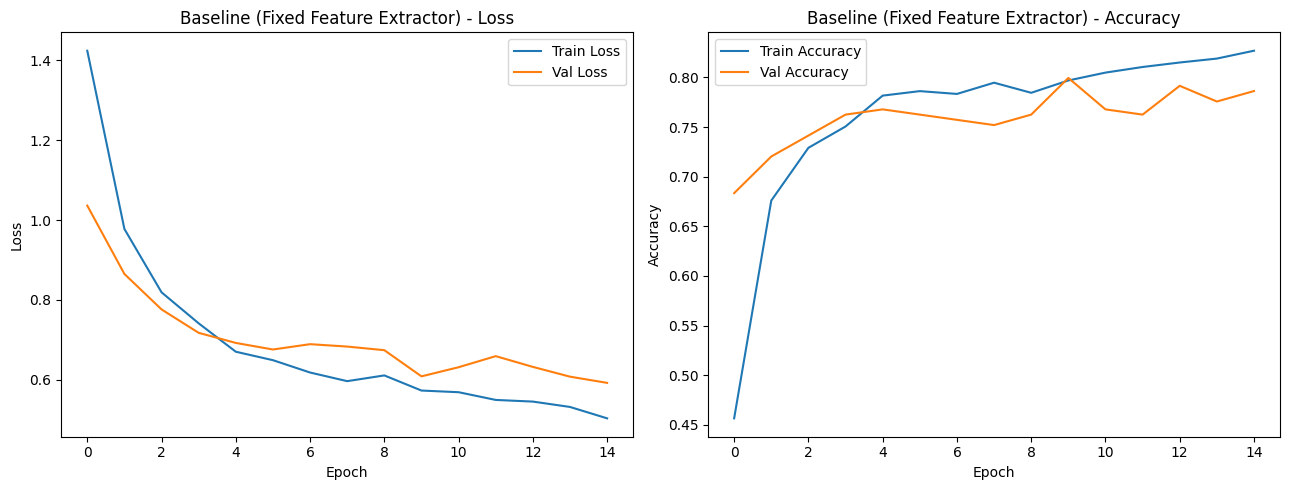

In [13]:
baseline_model, baseline_history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3
)

plot_history(baseline_history, title="Baseline (Fixed Feature Extractor)")

## 7. Cek Apakah Terjadi Overfitting

Cara ngeceknya gampang: lihat gap antara kurva train dan validasi.

- Kalau train loss terus turun tapi val loss malah naik (atau stagnan) di beberapa epoch terakhir, itu tanda overfitting.
- Kalau train accuracy jauh lebih tinggi dari val accuracy dan gap-nya makin lebar seiring epoch, itu juga tanda overfitting.

Kita hitung selisihnya secara eksplisit di bawah ini.

In [14]:
final_train_acc = baseline_history["train_acc"][-1]
final_val_acc = baseline_history["val_acc"][-1]
gap = final_train_acc - final_val_acc

print(f"Train accuracy akhir : {final_train_acc:.4f}")
print(f"Val accuracy akhir   : {final_val_acc:.4f}")
print(f"Gap train-val        : {gap:.4f}")

if gap > 0.1:
    print("Ada indikasi overfitting yang cukup signifikan.")
elif gap > 0.05:
    print("Ada sedikit indikasi overfitting.")
else:
    print("Nggak ada indikasi overfitting yang berarti.")

Train accuracy akhir : 0.8269
Val accuracy akhir   : 0.7863
Gap train-val        : 0.0406
Nggak ada indikasi overfitting yang berarti.


## 8. Penanganan Overfitting

Kalau dari hasil di atas ternyata ada indikasi overfitting, kita coba beberapa teknik yang sudah dibahas di kelas:

1. **Dropout** - biar model nggak terlalu bergantung sama kombinasi fitur tertentu
2. **Weight decay (L2 regularization)** - menekan bobot supaya nggak terlalu besar
3. **Early stopping** - berhenti latihan begitu val loss udah nggak membaik lagi, biar nggak lanjut "menghafal"
4. **Data augmentation** yang sudah kita pasang dari awal juga termasuk teknik penanganan overfitting, karena bikin variasi data training makin banyak


Epoch 1/15 - train_loss: 1.6887 - train_acc: 0.3190 - val_loss: 1.1870 - val_acc: 0.6042
Epoch 2/15 - train_loss: 1.2374 - train_acc: 0.5249 - val_loss: 0.9789 - val_acc: 0.6807
Epoch 3/15 - train_loss: 1.0655 - train_acc: 0.6018 - val_loss: 0.8682 - val_acc: 0.7203
Epoch 4/15 - train_loss: 0.9825 - train_acc: 0.6437 - val_loss: 0.8394 - val_acc: 0.7230
Epoch 5/15 - train_loss: 0.9121 - train_acc: 0.6533 - val_loss: 0.8093 - val_acc: 0.7203
Epoch 6/15 - train_loss: 0.9145 - train_acc: 0.6702 - val_loss: 0.7586 - val_acc: 0.7467
Epoch 7/15 - train_loss: 0.9228 - train_acc: 0.6612 - val_loss: 0.7144 - val_acc: 0.7625
Epoch 8/15 - train_loss: 0.8685 - train_acc: 0.6776 - val_loss: 0.7464 - val_acc: 0.7441
Epoch 9/15 - train_loss: 0.8305 - train_acc: 0.6855 - val_loss: 0.7129 - val_acc: 0.7546
Epoch 10/15 - train_loss: 0.8267 - train_acc: 0.6957 - val_loss: 0.6974 - val_acc: 0.7546
Epoch 11/15 - train_loss: 0.8285 - train_acc: 0.6957 - val_loss: 0.7045 - val_acc: 0.7573
Epoch 12/15 - train

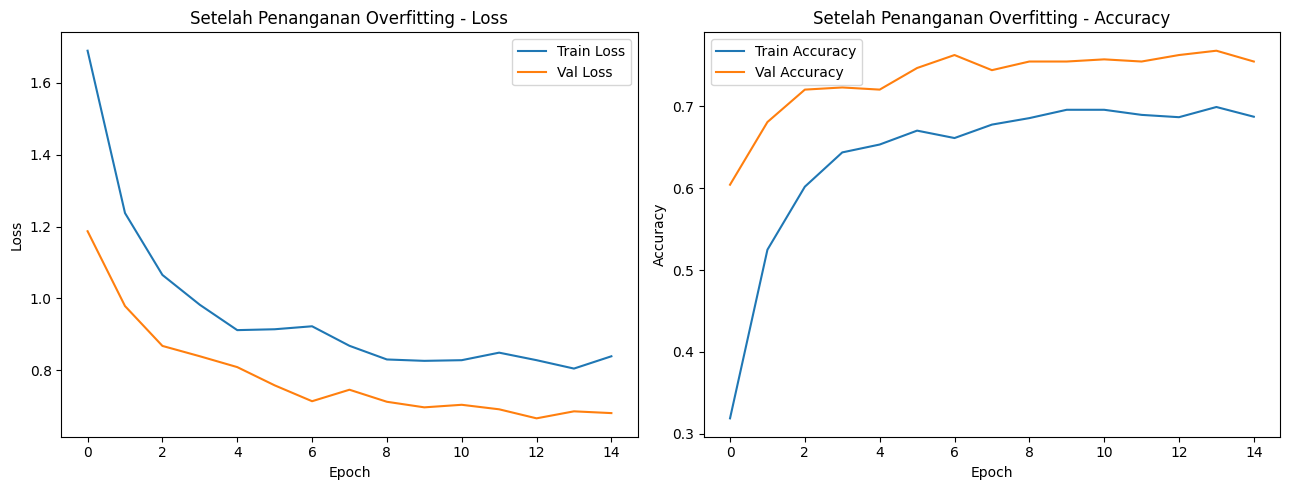

In [15]:
improved_model = build_model(num_classes=len(class_names), freeze_backbone=True, dropout=0.5)

improved_model, improved_history = train_model(
    improved_model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4
)

plot_history(improved_history, title="Setelah Penanganan Overfitting")

In [16]:
final_train_acc_improved = improved_history["train_acc"][-1]
final_val_acc_improved = improved_history["val_acc"][-1]
gap_improved = final_train_acc_improved - final_val_acc_improved

print(f"Train accuracy akhir : {final_train_acc_improved:.4f}")
print(f"Val accuracy akhir   : {final_val_acc_improved:.4f}")
print(f"Gap train-val        : {gap_improved:.4f}")

print()
print(f"Gap sebelum penanganan : {gap:.4f}")
print(f"Gap sesudah penanganan : {gap_improved:.4f}")

Train accuracy akhir : 0.6872
Val accuracy akhir   : 0.7546
Gap train-val        : -0.0674

Gap sebelum penanganan : 0.0406
Gap sesudah penanganan : -0.0674


Bandingkan angka gap sebelum dan sesudah di atas. Kalau gap-nya udah mengecil, berarti teknik penanganan overfitting yang dipakai berhasil bikin model lebih general, nggak cuma jago di data training doang.

Model yang dipakai untuk evaluasi final di bawah adalah `improved_model`, karena sudah melalui proses penanganan overfitting.

## 9. Evaluasi Final di Test Set

Test set ini belum pernah "dilihat" model sama sekali selama training maupun validasi, jadi hasil di sini paling mencerminkan performa model di dunia nyata.

In [17]:
improved_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = improved_model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.98      0.73      0.84        60
       glass       0.74      0.72      0.73        76
       metal       0.79      0.89      0.83        62
       paper       0.77      0.85      0.81        89
     plastic       0.79      0.86      0.82        73
       trash       0.58      0.35      0.44        20

    accuracy                           0.79       380
   macro avg       0.77      0.74      0.75       380
weighted avg       0.79      0.79      0.79       380



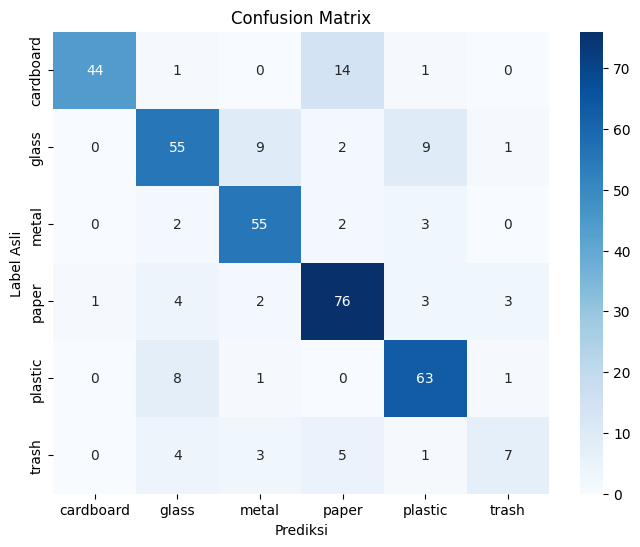

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.title("Confusion Matrix")
plt.show()

## 10. Kesimpulan

Beberapa poin yang bisa diambil dari eksperimen ini:

- Transfer learning pakai ResNet18 pretrained sebagai fixed feature extractor sudah cukup efektif buat klasifikasi jenis sampah, meskipun jumlah data cuma sekitar 2500-an gambar.
- Dari kurva training vs validasi, kita bisa lihat langsung apakah model mengalami overfitting atau tidak, cukup dengan membandingkan tren loss/accuracy di kedua set.
- Kalau muncul overfitting, kombinasi dropout, weight decay, dan early stopping (ditambah augmentasi data yang sudah dipasang dari awal) cukup ampuh buat menekan gap antara performa training dan validasi.
- Confusion matrix di atas bisa dipakai buat lihat kelas mana yang paling sering ketuker, biasanya kelas yang mirip secara visual (misalnya glass dan plastic) lebih rawan salah klasifikasi.